<a href="https://colab.research.google.com/github/Praharshita1275/python/blob/main/plant_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Load the dataset with splits and info
(train_ds, val_ds, test_ds), ds_info = tfds.load(
    'plant_village',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'], # Splitting the 'train' split
    shuffle_files=True,
    as_supervised=True, # Returns a tuple (image, label)
    with_info=True
)

# Print dataset info
num_classes = ds_info.features['label'].num_classes
print(f"Number of training samples: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation samples: {tf.data.experimental.cardinality(val_ds)}")
print(f"Number of test samples: {tf.data.experimental.cardinality(test_ds)}")
print(f"Number of classes: {num_classes}")

# Let's see what a few images look like
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(ds_info.features['label'].int2str(label))
    plt.axis("off")
plt.show()

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(image, label):
    # Resize the image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Normalize the pixel values to [0, 1]
    image = image / 255.0
    return image, label

# Apply preprocessing to all datasets
train_ds = train_ds.map(preprocess).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Data augmentation layer
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

# Build the model
model = keras.Sequential([
    # Input shape needs to be defined in the first layer
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Apply data augmentation
    data_augmentation,

    # Convolutional base
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(num_classes, activation='softmax') # Output layer
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Train the model
epochs = 50
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/50


I0000 00:00:1752769003.351997     325 cuda_dnn.cc:529] Loaded cuDNN version 90300


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.3012 - loss: 2.6552 - val_accuracy: 0.6347 - val_loss: 1.2530
Epoch 2/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.5426 - loss: 1.5576 - val_accuracy: 0.7372 - val_loss: 0.8815
Epoch 3/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.6171 - loss: 1.2433 - val_accuracy: 0.7588 - val_loss: 0.7445
Epoch 4/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.6721 - loss: 1.0671 - val_accuracy: 0.8026 - val_loss: 0.6161
Epoch 5/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.7075 - loss: 0.9376 - val_accuracy: 0.8518 - val_loss: 0.4753
Epoch 6/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.7313 - loss: 0.8417 - val_accuracy: 0.8402 - val_loss: 0.5365
Epoch 7/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.7541 - loss: 0.7655 - val_accuracy: 0.8691 - val_loss: 0.4109
Epoch 8/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.7802 - loss: 0.68

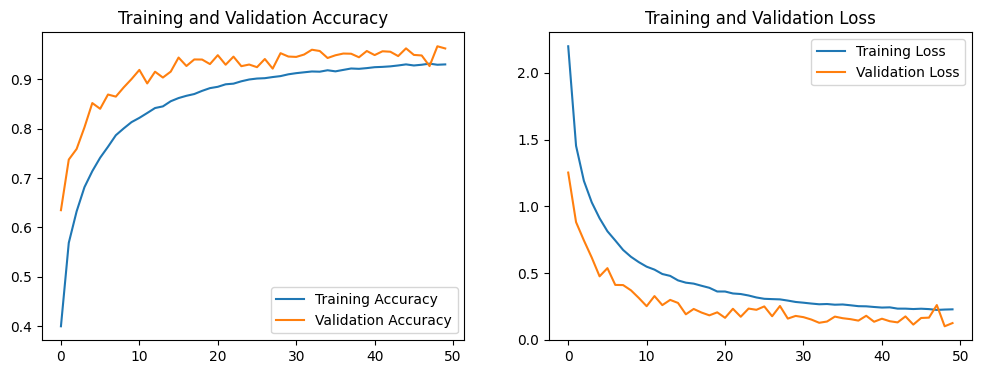

170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9665 - loss: 0.1064

Test accuracy: 0.97


In [ ]:
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Evaluate on the test set
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest accuracy: {test_acc:.2f}')

In [ ]:
# Provide a filename for the single-file .keras format
model.save('plant_village_model.keras')

print("✅ Model saved successfully as 'plant_village_model.keras'.")

✅ Model saved successfully as 'plant_village_model.keras'.


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# This script assumes you have a model saved in a directory
# named 'plant_village_saved_model' and the necessary datasets.

# --- 1. SETUP & LOAD DATA ---
print("Loading data...")
# Basic setup to make the script runnable
IMG_SIZE = 128
BATCH_SIZE = 64

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

# Load only the datasets needed for training
(train_ds, val_ds) = tfds.load(
    'plant_village',
    split=['train[:80%]', 'train[80%:90%]'],
    shuffle_files=True,
    as_supervised=True
)

train_ds = train_ds.map(preprocess).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# --- 2. LOAD THE PREVIOUSLY TRAINED MODEL ---
print("\n📦 Loading model from 'plant_village_saved_model'...")
model_to_resume = tf.keras.models.load_model('/kaggle/working/plant_village_model.keras')
print("Model loaded successfully.")


# --- 3. CONTINUE TRAINING FOR MORE EPOCHS 📈 ---
additional_epochs = 50
print(f"\n💪 Resuming training for {additional_epochs} more epochs...")

history_resumed = model_to_resume.fit(
    train_ds,
    validation_data=val_ds,
    epochs=additional_epochs
)


# --- 4. SAVE THE NEWLY TRAINED MODEL ---
print("\n💾 Saving the newly trained model...")
model_to_resume.save('plant_village_model_retrained.keras')
print("Model saved to 'plant_village_model_retrained' directory.")

Loading data...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

...

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


I0000 00:00:1752896769.159659      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752896769.160246      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



📦 Loading model from 'plant_village_saved_model'...
Model loaded successfully.

💪 Resuming training for 50 more epochs...
Epoch 1/50


I0000 00:00:1752896774.830191     328 cuda_dnn.cc:529] Loaded cuDNN version 90300


679/679 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.9440 - loss: 0.1744 - val_accuracy: 0.9611 - val_loss: 0.1236
Epoch 2/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9472 - loss: 0.1608 - val_accuracy: 0.9475 - val_loss: 0.1802
Epoch 3/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9484 - loss: 0.1640 - val_accuracy: 0.9565 - val_loss: 0.1477
Epoch 4/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9475 - loss: 0.1640 - val_accuracy: 0.9466 - val_loss: 0.1799
Epoch 5/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9470 - loss: 0.1703 - val_accuracy: 0.9696 - val_loss: 0.1026
Epoch 6/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9496 - loss: 0.1623 - val_accuracy: 0.9656 - val_loss: 0.1171
Epoch 7/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9426 - loss: 0.1810 - val_accuracy: 0.9619 - val_loss: 0.1160
Epoch 8/50
679/679 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9492 - loss: 0.1615 - val_accurac

In [ ]:
# Run this on your PC where you trained the model
import tensorflow_datasets as tfds

# Load dataset info to get the class names
ds_info = tfds.builder('plant_village').info
class_names = ds_info.features['label'].names

# Write the names to a file, one per line
with open('labels.txt', 'w') as f:
    for name in class_names:
        f.write(f"{name}\n")

print("✅ labels.txt created successfully.")

✅ labels.txt created successfully.


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# --- 1. Load the Saved Keras Model ---
saved_model_dir = '/kaggle/working/plant_village_model_retrained.keras'
model = tf.keras.models.load_model(saved_model_dir)

# --- 2. Create the TFLite Converter ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# --- 3. Set up for Integer Quantization ---
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset_gen():
    # Take a few batches from your validation data
    (val_ds, ) = tfds.load('plant_village', split=['train[80%:81%]'], as_supervised=True)

    # CORRECTED LINE: The map function now returns both the resized image and the label
    val_ds = val_ds.map(lambda img, lbl: (tf.image.resize(img, (128, 128)), lbl)).batch(1)

    # The loop will now work correctly
    for image, label in val_ds.take(100):
        yield [tf.cast(image, tf.float32)]

converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# --- 4. Convert the Model ---
print("⏳ Converting and quantizing the model...")
tflite_quant_model = converter.convert()
print("✅ Model converted successfully.")

# --- 5. Save the TFLite Model ---
with open('plant_village_quant.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("💾 Quantized TFLite model saved as 'plant_village_quant.tflite'")

⏳ Converting and quantizing the model...
Saved artifact at '/tmp/tmpv6nni1lj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  133176096740496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096741648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096739536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096740880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096741456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096742800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096740304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096737808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096741072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133176096736464: TensorSpec(shape=(), dtype

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1753175804.952039      36 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1753175804.952073      36 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ Model converted successfully.
💾 Quantized TFLite model saved as 'plant_village_quant.tflite'


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [ ]:
model = tf.keras.models.load_model('/kaggle/working/plant_village_model_retrained.keras')
loss, acc = model.evaluate(test_ds, verbose=2)

I0000 00:00:1753265685.929411      78 cuda_dnn.cc:529] Loaded cuDNN version 90300


170/170 - 4s - 23ms/step - accuracy: 0.9694 - loss: 0.1094


In [ ]:
import numpy as np
import tflite_runtime.interpreter as tflite
from PIL import Image

# 1. Load the TFLite model and allocate tensors.
interpreter = tflite.Interpreter(model_path="/kaggle/working/plant_village_quant.tflite")
interpreter.allocate_tensors()

# 2. Get input and output tensor details.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Load and prepare the input image.
# Get the expected input shape and type
input_shape = input_details[0]['shape'] # e.g., (1, 224, 224, 3)
height = input_shape[1]
width = input_shape[2]

# Load your image and resize it to the model's expected size.
image = Image.open("/kaggle/input/vgbsjk/Leaf spot disease.jpg").resize((width, height))

# Convert the image to a numpy array and add a batch dimension.
input_data = np.expand_dims(image, axis=0)

# Normalize the input data if required by the model (e.g., scale to [0, 1])
# Check the 'quantization' parameter in input_details to be sure.
# If the model is not quantized (float32), normalize it.
if input_details[0]['dtype'] == np.float32:
    input_data = (np.float32(input_data) - 127.5) / 127.5


# 4. Set the input tensor and run inference.
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# 5. Get the output from the output tensor.
output_data = interpreter.get_tensor(output_details[0]['index'])

# 6. Interpret the output.
# The output_data will be an array of probabilities.
predicted_class_index = np.argmax(output_data)
confidence_score = output_data[0][predicted_class_index]

print(f"Predicted class index: {predicted_class_index}")
print(f"Confidence score: {confidence_score}")

# You can map the index to your class names (e.g., from a labels.txt file)
# class_labels = ["Disease A", "Disease B", "Healthy"]
# print(f"Predicted class: {class_labels[predicted_class_index]}")

ValueError: Mmap of '122' at offset '0' failed with error '22'.

In [ ]:
!pip install tflite-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.0 MB/s eta 0:00:0000:0100:01
